# Rope Flow — Stage 2: Data-Driven Trajectory Reconstruction

---

**Input**: Stage 1 processed CSVs — quaternion orientation and gravity-removed world-frame acceleration at 50 Hz, one file per hand.

| Stage | Method | Role |
|-------|--------|------|
| **2A** | SINDy — sparse identification of governing dynamics | Discovers the ODE governing hand motion from data |
| **2B** | PINN — physics-informed trajectory reconstruction | Recovers 3D position from IMU using discovered physics as prior |
| **2C** | DMD + PCA — mode extraction and feature representation | Compresses each cycle into a feature vector for Stage 3 classification |

---
## 0. Setup & Data Loading

In [ ]:
import glob, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from mpl_toolkits.mplot3d import Axes3D
from scipy import signal, integrate
from scipy.linalg import svd
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torch.optim as optim
import pysindy as ps
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
torch.manual_seed(42)

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
})
C = {'dev0': '#5DCAA5', 'dev1': '#7F77DD',
     'naive': '#E24B4A', 'pinn': '#EF9F27', 'gray': '#888780'}

# ── Cycle detection parameters — must match Stage 1 ──────────
# Stage 1 detects cycles using SavGol-smoothed ||omega|| magnitude
# with a physical prominence threshold in deg/s.
# We replicate the same logic here so cycle boundaries are consistent.
CYCLE_PROMINENCE_RADS = 100.0 * np.pi / 180   # 100 deg/s converted to rad/s
CYCLE_MIN_PERIOD_S    = 0.5                    # seconds

pysindy: 2.1.0 | torch: 2.10.0+cpu


In [3]:
data_dir  = '../../data/processed'
csv_files = sorted(glob.glob(os.path.join(data_dir, '*.csv')))

d0 = pd.read_csv([f for f in csv_files if 'device0' in f][0])
d1 = pd.read_csv([f for f in csv_files if 'device1' in f][0])

print(f'Device 0 (right): {len(d0)} samples | {d0.timestamp_ms.iloc[-1]/1000:.1f} s | '
      f'{1000/d0.timestamp_ms.diff().median():.0f} Hz')
print(f'Device 1 (left):  {len(d1)} samples | {d1.timestamp_ms.iloc[-1]/1000:.1f} s | '
      f'{1000/d1.timestamp_ms.diff().median():.0f} Hz')
d0.head(3)

Device 0 (right): 2254 samples | 45.1 s | 50 Hz
Device 1 (left):  2256 samples | 45.1 s | 50 Hz


,timestamp_ms,qw,qx,qy,qz,ax_w,ay_w,az_w
0,0.000000,0.924367,-0.315881,0.213688,-0.010088,4.477258,8.565360,6.548588
1,20.000444,0.921407,-0.320444,0.219019,-0.018837,4.579068,8.571022,6.309780
2,40.000888,0.918007,-0.326960,0.222859,-0.026367,4.675477,8.547899,5.997823


In [ ]:
def preprocess(df):
    """
    Extract all signals from a processed CSV and build the SINDy orientation state.

    Directly extracts angular velocity (gx, gy, gz) from the processed CSV, 
    converting from deg/s to rad/s for physical consistency in SINDy state O.

    SINDy state O uses sin/cos encoding for roll and yaw to avoid the
    discontinuities at +-pi that would appear as spurious high-frequency
    terms in the library. Pitch is kept raw since it stays in (-pi/2, pi/2).

    Returns
    -------
    t     : (N,)   time [s]
    Q     : (N,4)  quaternion [qw, qx, qy, qz]
    A     : (N,3)  world-frame linear acceleration [m/s^2]
    omega : (N,3)  angular velocity [rad/s]
    O     : (N,8)  SINDy state [sin(r), cos(r), pitch, sin(y), cos(y), wx, wy, wz]
    """
    t = df['timestamp_ms'].values / 1000.0
    Q = df[['qw','qx','qy','qz']].values
    A = df[['ax_w','ay_w','az_w']].values

    # Direct extraction of angular velocity from CSV (converted to rad/s)
    # Assumes Stage 1 saved these as 'gx', 'gy', 'gz' in deg/s
    omega = df[['gx', 'gy', 'gz']].values * (np.pi / 180.0)

    qw, qx, qy, qz = Q[:,0], Q[:,1], Q[:,2], Q[:,3]

    roll  = np.arctan2(2*(qw*qx + qy*qz), 1 - 2*(qx**2 + qy**2))
    pitch = np.arcsin(np.clip(2*(qw*qy - qz*qx), -1, 1))
    yaw   = np.arctan2(2*(qw*qz + qx*qy), 1 - 2*(qy**2 + qz**2))

    # SINDy state vector: [sin(r), cos(r), p, sin(y), cos(y), wx, wy, wz]
    O = np.column_stack([
        np.sin(roll), np.cos(roll), pitch,
        np.sin(yaw),  np.cos(yaw),
        omega
    ])
    
    return t, Q, A, omega, O

State matrices: (2254, 8), (2256, 8)
Acceleration bias (residual from Stage 1):
  D0: X=1.224  Y=-0.506  Z=-0.736 m/s²
  D1: X=0.558  Y=1.469  Z=0.545 m/s²


### 0.1 — Cycle Segmentation & Time-Overlap Pairing

Cycle boundaries are detected using the same method as Stage 1: Savitzky-Golay smoothed angular velocity magnitude with a physical prominence threshold in rad/s. Working per-cycle is essential — it bounds the drift window for integration and gives SINDy a stationary training segment.

Cycles are then paired across devices by maximum time-window overlap rather than index alignment, which correctly handles the different cycle counts that arise when the two devices detect slightly different numbers of peaks.

In [5]:
def detect_cycles(t, omega, label=''):
    """
    Detect rope-flow cycles from the angular velocity magnitude ||omega||.
    Replicates Stage 1 logic: SavGol smoothing + physical prominence threshold.
    Boundaries are placed at midpoints between consecutive peaks.
    """
    mag        = np.linalg.norm(omega, axis=1)   # rad/s
    mag_smooth = signal.savgol_filter(mag, window_length=15, polyorder=3)
    sr         = 1.0 / np.median(np.diff(t))

    peaks, _   = signal.find_peaks(
        mag_smooth,
        distance=int(CYCLE_MIN_PERIOD_S * sr),
        prominence=CYCLE_PROMINENCE_RADS
    )
    bounds = ([0]
              + [(peaks[i]+peaks[i+1])//2 for i in range(len(peaks)-1)]
              + [len(t)-1])
    cycles    = [(bounds[i], bounds[i+1]) for i in range(len(bounds)-1)]
    durations = [t[e]-t[s] for s,e in cycles]

    print(f'{label}: {len(peaks)} peaks -> {len(cycles)} cycles | '
          f'mean T = {np.mean(durations):.2f} s  '
          f'CV = {np.std(durations)/np.mean(durations):.2f}')
    return cycles, mag_smooth, peaks


def pair_cycles_by_overlap(t0, cycles0, t1, cycles1):
    """
    Match each Device 0 cycle to the Device 1 cycle with maximum
    time-window overlap. Each Device 1 cycle is used at most once.
    """
    def overlap(s0, e0, s1, e1):
        return max(0.0, min(t0[e0], t1[e1]) - max(t0[s0], t1[s1]))

    paired0, paired1, used = [], [], set()
    for c0 in cycles0:
        best_idx, best_ov = -1, -1.0
        for i, c1 in enumerate(cycles1):
            if i in used: continue
            ov = overlap(c0[0], c0[1], c1[0], c1[1])
            if ov > best_ov:
                best_ov, best_idx = ov, i
        if best_idx >= 0 and best_ov > 0:
            paired0.append(c0)
            paired1.append(cycles1[best_idx])
            used.add(best_idx)
    return paired0, paired1


raw_cyc0, om0_smooth, peaks0 = detect_cycles(t0, om0, label='Device 0')
raw_cyc1, om1_smooth, peaks1 = detect_cycles(t1, om1, label='Device 1')

cycles0, cycles1 = pair_cycles_by_overlap(t0, raw_cyc0, t1, raw_cyc1)
n_cycles = len(cycles0)
print(f'Paired cycles: {n_cycles}  (D0: {len(raw_cyc0)}, D1: {len(raw_cyc1)})')

Device 0: 45 peaks -> 45 cycles | mean T = 1.00 s  CV = 0.45
Device 1: 39 peaks -> 39 cycles | mean T = 1.16 s  CV = 0.47
Paired cycles: 39  (D0: 45, D1: 39)


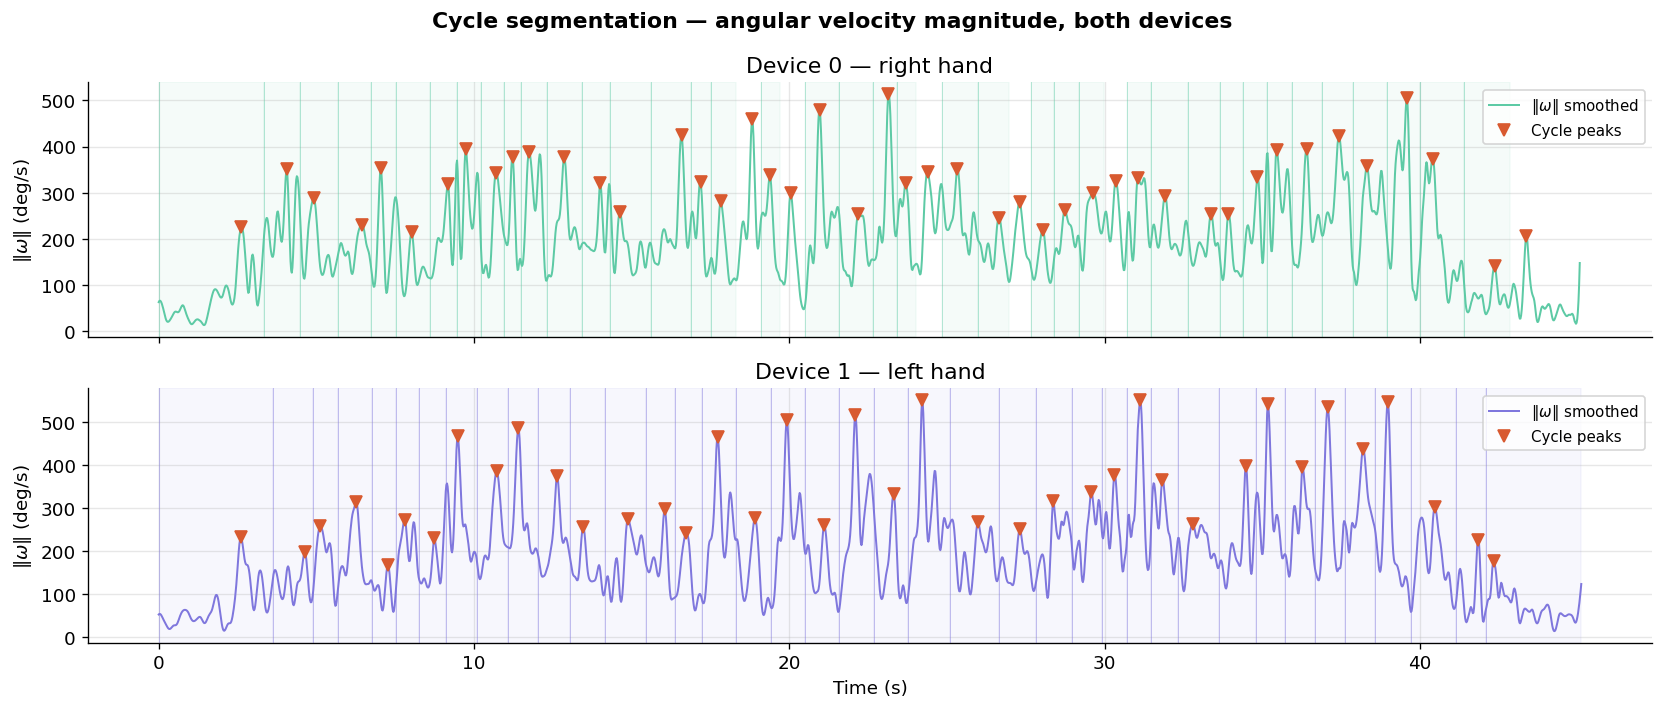

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
for ax, t, sm, pks, cycs, label, col in [
    (axes[0], t0, om0_smooth, peaks0, cycles0, 'Device 0 — right hand', C['dev0']),
    (axes[1], t1, om1_smooth, peaks1, cycles1, 'Device 1 — left hand',  C['dev1']),
]:
    ax.plot(t, sm * 180/np.pi, color=col, lw=1.2, label='$\\|\\omega\\|$ smoothed')
    ax.plot(t[pks], sm[pks] * 180/np.pi, 'v', color='#D85A30', ms=7, label='Cycle peaks')
    for s, e in cycs:
        ax.axvspan(t[s], t[e], alpha=0.06, color=col)
        ax.axvline(t[s], color=col, lw=0.6, alpha=0.4)
    ax.set_ylabel('$\\|\\omega\\|$ (deg/s)')
    ax.set_title(label)
    ax.legend(fontsize=9, loc='upper right')
axes[-1].set_xlabel('Time (s)')
plt.suptitle('Cycle segmentation — angular velocity magnitude, both devices',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2A — SINDy: Sparse Identification of Governing Dynamics

**Goal**: Discover the equations of motion governing hand dynamics directly from data.

**State vector** — smooth orientation representation (8-dim):
$$\mathbf{x}(t) = [\sin\phi,\ \cos\phi,\ \theta,\ \sin\psi,\ \cos\psi,\ \omega_x,\ \omega_y,\ \omega_z]^\top$$

Raw IMU acceleration was tested first but has derivative variance ≈ 167 m/s³, which SINDy cannot model sparsely. The orientation state has variance ≈ 2 rad/s² — three orders of magnitude lower. The sin/cos encoding of roll and yaw removes discontinuities at ±π that would otherwise appear as spurious high-frequency library terms.

**Joint fit**: both devices are stacked into one training set. If the discovered equations generalise across devices (R² D1 ≈ R² D0), they reflect true rope-flow dynamics rather than device-specific artefacts.

**Link to Stage 2B**: the discovered dynamics become the physics prior in the PINN loss function.

In [7]:
# Stack both devices for joint fit
X_joint = np.vstack([O0, O1])
t_joint = np.concatenate([t0, t1 + t0[-1] + 0.02])

library     = ps.GeneralizedLibrary([
    ps.PolynomialLibrary(degree=2, include_bias=True),
    ps.FourierLibrary(n_frequencies=1)
])
optimizer      = ps.STLSQ(threshold=0.05, alpha=0.05, max_iter=20)
differentiator = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 11})

model = ps.SINDy(feature_library=library, optimizer=optimizer,
                 differentiation_method=differentiator)
model.fit(X_joint, t=t_joint)
model.print()

print(f'\nR² joint (train): {model.score(X_joint, t=t_joint):.4f}')
print(f'R² Device 0:      {model.score(O0, t=t0):.4f}')
print(f'R² Device 1:      {model.score(O1, t=t1):.4f}  <- cross-device generalisation')

(x0)' =  36.261 1 +  2.256 x0 +  0.611 x1 +  1.815 x2 + -1.030 x3 + -3.224 x4 + -70.826 x0^2 +  0.152 x0 x1 + -0.174 x0 x2 + -0.121 x0 x3 +  0.120 x0 x7 +  85.446 x1^2 +  0.343 x1 x2 +  0.104 x1 x3 +  0.056 x1 x4 +  1.000 x1 x5 +  0.068 x1 x7 + -9.078 x2^2 + -0.345 x2 x3 + -0.252 x2 x4 +  1.004 x2 x7 + -3.381 x3^2 + -20.449 x4^2 + -2.566 sin(1 x0) + -173.678 cos(1 x0) + -0.700 sin(1 x1) +  166.572 cos(1 x1) + -2.000 sin(1 x2) + -19.758 cos(1 x2) +  1.125 sin(1 x3) +  14.242 cos(1 x3) +  3.675 sin(1 x4) + -22.842 cos(1 x4) +  0.091 sin(1 x5) +  0.100 cos(1 x5) + -0.081 cos(1 x6) +  0.058 cos(1 x7)
(x1)' =  17.209 1 +  0.263 x0 + -2.768 x1 +  4.519 x2 +  2.190 x3 +  1.871 x4 +  0.062 x7 + -39.920 x0^2 +  0.184 x0 x1 +  0.220 x0 x2 + -0.995 x0 x5 +  0.080 x0 x6 + -0.140 x0 x7 +  39.800 x1^2 +  0.339 x1 x2 +  0.345 x1 x3 +  0.095 x1 x7 + -0.660 x2^2 + -0.349 x2 x3 + -0.961 x2 x6 + -0.141 x2 x7 +  30.234 x3^2 +  0.066 x3 x5 + -40.088 x4^2 + -0.053 x4 x5 + -0.368 sin(1 x0) + -90.973 cos(1 x0

### 2A.1 — Threshold Sweep: Sparsity–Accuracy Pareto Front

The STLSQ threshold controls the sparsity–accuracy tradeoff. We sweep a range of thresholds and select the point that gives the best balance: high enough R² to capture the dynamics, sparse enough that the model is interpretable and generalisable.

In [8]:
thresholds  = [0.01, 0.05, 0.1, 0.2, 0.4, 0.8]
sindy_sweep = {}

for th in thresholds:
    m = ps.SINDy(
        feature_library=ps.GeneralizedLibrary([
            ps.PolynomialLibrary(degree=2, include_bias=True),
            ps.FourierLibrary(n_frequencies=1)
        ]),
        optimizer=ps.STLSQ(threshold=th, alpha=0.05, max_iter=20),
        differentiation_method=ps.SmoothedFiniteDifference(
            smoother_kws={'window_length': 11})
    )
    m.fit(X_joint, t=t_joint)
    r2       = m.score(X_joint, t=t_joint)
    r2_cross = m.score(O1, t=t1)
    c        = m.coefficients()
    sindy_sweep[th] = {
        'model':    m,
        'r2':       r2,
        'r2_cross': r2_cross,
        'sparsity': (c == 0).mean(),
        'n_active': int((c != 0).sum())
    }
    print(f'th={th:.2f}  R²={r2:.4f}  R²_cross={r2_cross:.4f}  '
          f'sparsity={(c==0).mean():.1%}  active={(c!=0).sum()}')

# Select threshold: highest cross-device R² among models with sparsity > 50%
# Cross-device R² is the better selection criterion — it rewards generalisation
candidates = {th: v for th, v in sindy_sweep.items() if v['sparsity'] > 0.5}
BEST_TH    = max(candidates, key=lambda th: candidates[th]['r2_cross'])
best_model = sindy_sweep[BEST_TH]['model']
print(f'\nSelected threshold: {BEST_TH}  '
      f'(best cross-device R² among models with sparsity > 50%)')

th=0.01  R²=0.3970  R²_cross=0.4342  sparsity=13.3%  active=423
th=0.05  R²=0.3907  R²_cross=0.4259  sparsity=28.3%  active=350
th=0.10  R²=0.3815  R²_cross=0.4134  sparsity=37.9%  active=303
th=0.20  R²=0.3661  R²_cross=0.4064  sparsity=47.5%  active=256
th=0.40  R²=0.3432  R²_cross=0.3653  sparsity=59.6%  active=197
th=0.80  R²=0.3296  R²_cross=0.3577  sparsity=65.8%  active=167

Selected threshold: 0.4  (best cross-device R² among models with sparsity > 50%)


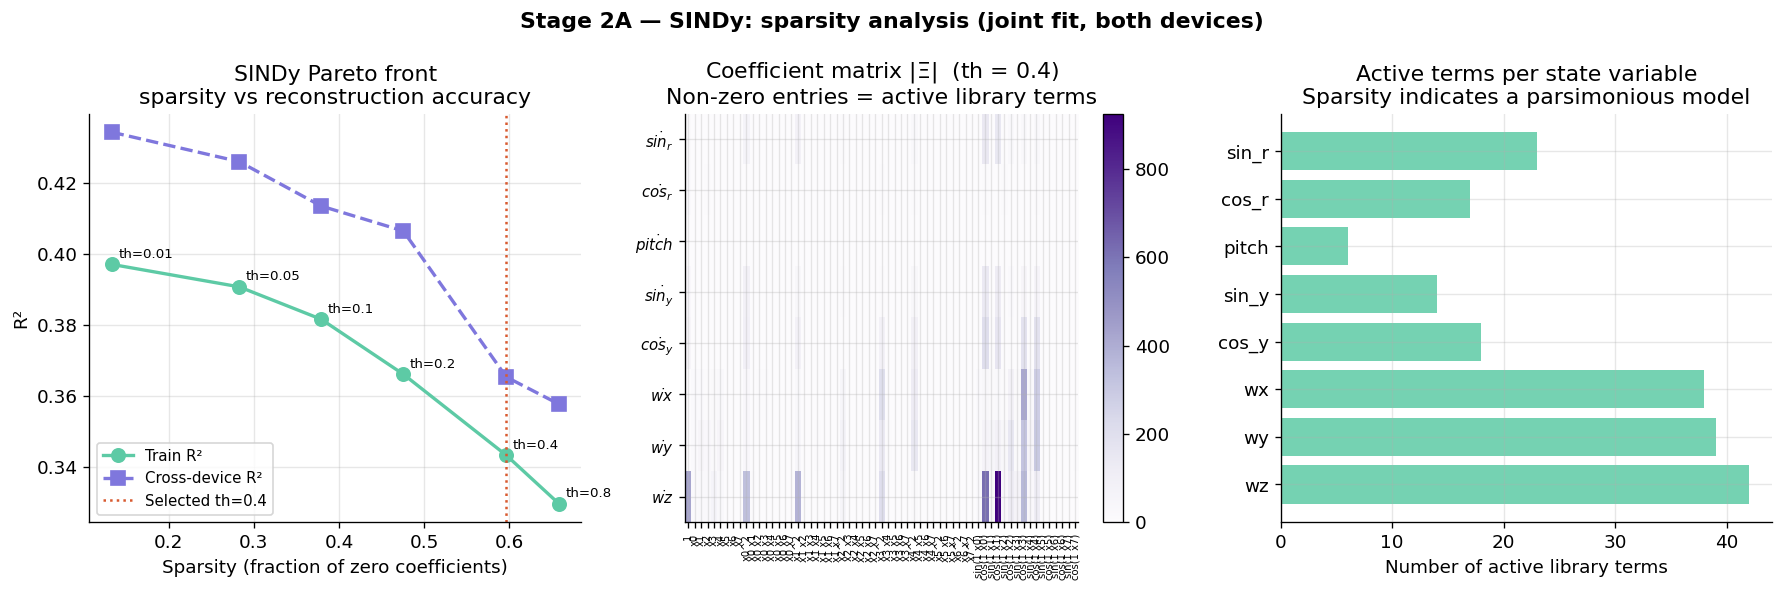

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ths      = list(sindy_sweep.keys())
r2s      = [sindy_sweep[t]['r2']       for t in ths]
r2_cross = [sindy_sweep[t]['r2_cross'] for t in ths]
sprs     = [sindy_sweep[t]['sparsity'] for t in ths]

# Pareto front: show both train and cross-device R²
axes[0].plot(sprs, r2s,      'o-', color=C['dev0'], ms=8, lw=2, label='Train R²')
axes[0].plot(sprs, r2_cross, 's--', color=C['dev1'], ms=8, lw=2, label='Cross-device R²')
for th, s, r in zip(ths, sprs, r2s):
    axes[0].annotate(f'th={th}', (s, r), textcoords='offset points',
                     xytext=(4, 4), fontsize=8)
axes[0].axvline(sindy_sweep[BEST_TH]['sparsity'], color='#D85A30',
                lw=1.5, ls=':', label=f'Selected th={BEST_TH}')
axes[0].set_xlabel('Sparsity (fraction of zero coefficients)')
axes[0].set_ylabel('R²')
axes[0].set_title('SINDy Pareto front\nsparsity vs reconstruction accuracy')
axes[0].legend(fontsize=9)

# Coefficient heatmap
coef       = best_model.coefficients()
feat_names = best_model.feature_library.get_feature_names()
im = axes[1].imshow(np.abs(coef), aspect='auto', cmap='Purples',
                    interpolation='nearest')
axes[1].set_xticks(range(len(feat_names)))
axes[1].set_xticklabels(feat_names, rotation=90, fontsize=6)
axes[1].set_yticks(range(len(sindy_names)))
axes[1].set_yticklabels([f'$\\dot{{{s}}}$' for s in sindy_names], fontsize=9)
axes[1].set_title(f'Coefficient matrix $|\\Xi|$  (th = {BEST_TH})\n'
                  f'Non-zero entries = active library terms')
plt.colorbar(im, ax=axes[1])

# Active terms per state variable
axes[2].barh(sindy_names, (coef != 0).sum(axis=1), color=C['dev0'], alpha=0.85)
axes[2].set_xlabel('Number of active library terms')
axes[2].set_title('Active terms per state variable\nSparsity indicates a parsimonious model')
axes[2].invert_yaxis()

plt.suptitle('Stage 2A — SINDy: sparsity analysis (joint fit, both devices)',
             fontweight='bold')
plt.tight_layout()
plt.show()

### 2A.2 — Discovered Equations & Validation

In [10]:
print(f'Discovered equations  (threshold = {BEST_TH}):')
best_model.print()
print(f'\nR² Device 0 (train):  {best_model.score(O0, t=t0):.4f}')
print(f'R² Device 1 (unseen): {best_model.score(O1, t=t1):.4f}')
print(f'Active terms: {sindy_sweep[BEST_TH]["n_active"]}  '
      f'out of {best_model.coefficients().size}  '
      f'({sindy_sweep[BEST_TH]["sparsity"]:.1%} sparse)')

Discovered equations  (threshold = 0.4):
(x0)' =  17.857 1 +  2.358 x0 + -0.287 x1 +  1.821 x2 + -0.808 x3 + -2.679 x4 + -56.242 x0^2 +  76.288 x1^2 +  0.991 x1 x5 + -8.582 x2^2 +  0.981 x2 x7 + -1.079 x3^2 + -19.863 x4^2 + -2.609 sin(1 x0) + -142.685 cos(1 x0) +  0.331 sin(1 x1) +  145.943 cos(1 x1) + -2.012 sin(1 x2) + -18.890 cos(1 x2) +  0.881 sin(1 x3) +  19.611 cos(1 x3) +  3.113 sin(1 x4) + -21.057 cos(1 x4)
(x1)' =  13.357 1 + -2.318 x1 +  4.337 x2 +  1.637 x3 +  1.773 x4 +  0.687 x0^2 + -0.957 x0 x5 +  2.614 x1^2 + -0.953 x2 x6 + -3.983 x3^2 + -7.485 x4^2 + -4.100 cos(1 x0) +  2.553 sin(1 x1) + -4.941 sin(1 x2) + -1.839 sin(1 x3) + -2.013 sin(1 x4) + -8.034 cos(1 x4)
(x2)' = -2.610 x0^2 + -0.992 x0 x7 + -2.607 x1^2 +  0.994 x1 x6 +  2.607 x3^2 +  2.613 x4^2
(x3)' =  27.133 1 +  2.198 x1 + -81.537 x0^2 +  36.055 x1^2 + -4.944 x2^2 +  0.531 x2 x4 + -9.702 x3^2 +  34.312 x4^2 + -134.949 cos(1 x0) + -2.539 sin(1 x1) +  120.092 cos(1 x1) + -10.898 cos(1 x2) + -44.225 cos(1 x3) +  5

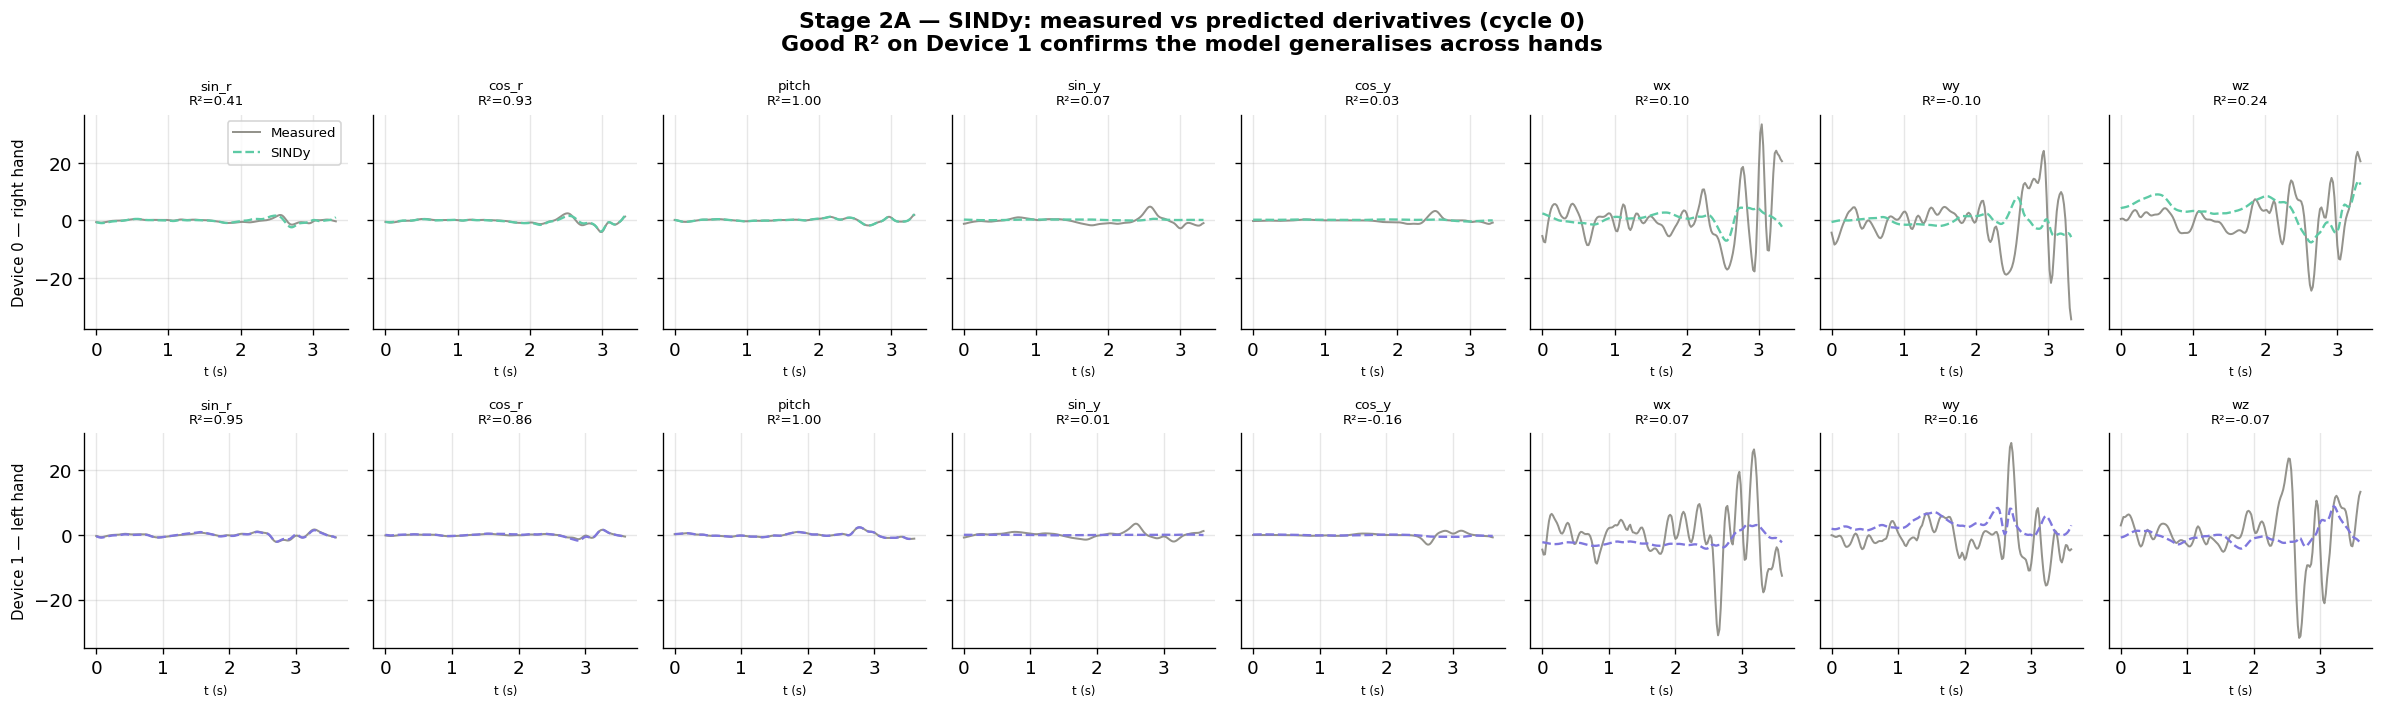

In [11]:
# Validate on cycle 0 of each device: compare true derivatives vs SINDy prediction.
# We use predict() (evaluates Xi*Theta(x)) rather than simulate() (integrates the ODE)
# to avoid stiffness issues from the high-frequency rope flow dynamics.
fig, axes = plt.subplots(2, 8, figsize=(20, 6), sharey='row')

for row, (O_dev, t_dev, cycs, label, col) in enumerate([
    (O0, t0, cycles0, 'Device 0 — right hand', C['dev0']),
    (O1, t1, cycles1, 'Device 1 — left hand',  C['dev1']),
]):
    s, e    = cycs[0]
    t_cyc   = t_dev[s:e]
    O_cyc   = O_dev[s:e]
    dO_pred = best_model.predict(O_cyc)
    dO_true = np.gradient(O_cyc, t_cyc, axis=0)

    for i, name in enumerate(sindy_names):
        axes[row, i].plot(t_cyc, dO_true[:, i], color=C['gray'],
                          lw=1.2, alpha=0.9, label='Measured')
        axes[row, i].plot(t_cyc, dO_pred[:, i], color=col,
                          lw=1.4, ls='--', label='SINDy')
        r2 = 1 - np.var(dO_true[:,i] - dO_pred[:,i]) / (np.var(dO_true[:,i]) + 1e-10)
        axes[row, i].set_title(f'{name}\nR²={r2:.2f}', fontsize=8)
        axes[row, i].set_xlabel('t (s)', fontsize=7)
        if i == 0:
            axes[row, i].set_ylabel(label, fontsize=9)

axes[0, 0].legend(fontsize=8)
plt.suptitle('Stage 2A — SINDy: measured vs predicted derivatives (cycle 0)\n'
             'Good R² on Device 1 confirms the model generalises across hands',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2B — PINN: Trajectory Reconstruction as an Inverse Problem

**Goal**: Recover the 3D hand position $\mathbf{p}(t)$ from IMU observations, using the SINDy-discovered dynamics as a physics prior.

**Why this is an inverse problem**: We have noisy $\hat{\mathbf{a}}(t)$ and want $\mathbf{p}(t)$ such that $\ddot{\mathbf{p}} \approx \hat{\mathbf{a}}$ while satisfying physical constraints.

**Corrector strategy**: rather than integrating from scratch, we compute a baseline trajectory $\mathbf{p}_{\text{base}}(t)$ and train a network to learn the correction $\delta\mathbf{p}(t)$. The baseline uses `scipy.signal.detrend` per cycle, which removes both the mean and linear trend from the acceleration — this handles the ~1.2 m/s² residual bias from Stage 1 gravity removal that a simple zero-mean subtraction cannot fully address.

**Composite loss** (weights reflect relative importance):
$$\mathcal{L} = \underbrace{5\,\|\mathbf{p}(T)-\mathbf{p}(0)\|^2}_{\text{position closure}} + \underbrace{2\,\|\mathbf{v}(T)-\mathbf{v}(0)\|^2}_{\text{velocity closure}} + \underbrace{\|\ddot{\mathbf{p}}-\hat{\mathbf{a}}\|^2}_{\text{data}} + \lambda\underbrace{(\mathcal{L}_{\text{boundary}} + \mathcal{L}_{\text{jerk}} + \mathcal{L}_{\text{energy}})}_{\text{physics}} + \lambda_{\text{sym}}\,\mathcal{L}_{\text{symmetry}}$$

Position and velocity closure are the primary anti-drift signals — they give the network a non-trivial gradient that forces the trajectory to close. The symmetry term couples both hands via the rope midpoint.

### 2B.1 — Baseline Integration with Linear Detrending

In [12]:
from scipy.signal import detrend as scipy_detrend

def integrate_cycle(t, A, s, e):
    """
    Double-integrate acceleration within one cycle using linear detrending.

    Linear detrending (scipy.signal.detrend) removes both the mean and the
    linear trend from each acceleration channel before integration. This is
    stronger than zero-mean subtraction: for periodic motion the true
    acceleration has zero mean AND zero net linear drift over one cycle.
    Any residual linear trend is sensor bias (gravity residual from Stage 1)
    that integrates to a cubic position error. Removing it reduces the
    baseline drift from ~1 m/cycle to a much smaller value.
    """
    tc = t[s:e]
    Ac = np.column_stack([scipy_detrend(A[s:e, d]) for d in range(3)])
    v  = np.column_stack([
        integrate.cumulative_trapezoid(Ac[:, d], tc, initial=0) for d in range(3)
    ])
    p  = np.column_stack([
        integrate.cumulative_trapezoid(v[:, d],  tc, initial=0) for d in range(3)
    ])
    return tc, v, p


naive_cycs0, naive_cycs1 = [], []
for (s0, e0), (s1, e1) in zip(cycles0, cycles1):
    tc0, vc0, pc0 = integrate_cycle(t0, A0, s0, e0)
    tc1, vc1, pc1 = integrate_cycle(t1, A1, s1, e1)
    naive_cycs0.append({'t': tc0, 'v': vc0, 'p': pc0, 's': s0, 'e': e0})
    naive_cycs1.append({'t': tc1, 'v': vc1, 'p': pc1, 's': s1, 'e': e1})

naive_drift0 = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in naive_cycs0]
naive_drift1 = [np.linalg.norm(c['p'][-1] - c['p'][0]) for c in naive_cycs1]
print(f'Baseline drift (detrended integration):')
print(f'  Device 0: mean = {np.mean(naive_drift0):.4f} m  '
      f'std = {np.std(naive_drift0):.4f} m')
print(f'  Device 1: mean = {np.mean(naive_drift1):.4f} m  '
      f'std = {np.std(naive_drift1):.4f} m')

Baseline drift (detrended integration):
  Device 0: mean = 0.1666 m  std = 0.0798 m
  Device 1: mean = 0.1585 m  std = 0.0766 m


### 2B.2 — PINN Architecture & Loss

In [13]:
class PINNCorrectorNet(nn.Module):
    """
    Learns the position correction delta_p(t) on top of the baseline trajectory.

    Input features (8-dim per timestep):
        t_norm                           normalised time in [0, 1]
        sin(2*pi*t), cos(2*pi*t)        fundamental period encoding
        sin(4*pi*t), cos(4*pi*t)        2nd harmonic encoding
        ax, ay, az                       detrended acceleration

    The harmonic time encoding lets the network represent the periodic
    structure of rope flow without relying on recurrence.
    Xavier initialisation with small gain (0.1) keeps delta_p near zero
    at the start — the baseline is the default, corrections are learned.
    """
    def __init__(self, hidden_dim=128, n_layers=5):
        super().__init__()
        layers = [nn.Linear(8, hidden_dim), nn.Tanh()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 3))
        self.net = nn.Sequential(*layers)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight, gain=0.1)
                nn.init.zeros_(layer.bias)

    def forward(self, feats):
        return self.net(feats)


def make_features(tc, Ac_dt):
    """Build 8-dim input feature tensor for one cycle."""
    T      = tc[-1] - tc[0]
    t_norm = (tc - tc[0]) / (T + 1e-8)
    return torch.tensor(np.column_stack([
        t_norm,
        np.sin(2*np.pi*t_norm), np.cos(2*np.pi*t_norm),
        np.sin(4*np.pi*t_norm), np.cos(4*np.pi*t_norm),
        Ac_dt
    ]), dtype=torch.float32)


def physics_losses(p, v, tc, R_arm=0.65, g=9.81):
    """
    Physics regularisation terms for one device's trajectory.

    periodic_p : position closure — p(T) = p(0)
    periodic_v : velocity closure — v(T) = v(0), prevents velocity drift
    boundary   : arm-length constraint, ReLU(||p|| - R_arm)^2
    jerk       : minimise third derivative — human motion is smooth
    energy     : KE + PE variance — energy should be cyclic, not drift
    """
    dt     = float(np.median(np.diff(tc)))
    L_pp   = torch.norm(p[-1] - p[0]) ** 2
    L_pv   = torch.norm(v[-1] - v[0]) ** 2
    L_bnd  = (torch.relu(torch.norm(p, dim=1) - R_arm) ** 2).mean()
    jerk   = torch.diff(torch.diff(torch.diff(p, dim=0)/dt, dim=0)/dt, dim=0)/dt
    L_jerk = (jerk**2).sum(dim=1).mean()
    L_en   = (0.5*(v**2).sum(dim=1) + g*p[:,2]).var()
    return {'periodic_p': L_pp, 'periodic_v': L_pv,
            'boundary': L_bnd, 'jerk': L_jerk, 'energy': L_en}


def symmetry_loss(p0, p1):
    """
    Rope midpoint stability: the centre-of-mass of both hands should
    remain near a fixed point — it should not drift across the cycle.
    """
    n   = min(len(p0), len(p1))
    mid = (p0[:n] + p1[:n]) / 2.0
    return ((mid - mid.mean(dim=0, keepdim=True))**2).sum(dim=1).mean()


n_params = sum(p.numel() for p in PINNCorrectorNet().parameters())
print(f'Architecture: MLP [8 -> 128 x 4 -> 3]  |  '
      f'Tanh activations  |  {n_params:,} parameters')

Architecture: MLP [8 -> 128 x 4 -> 3]  |  Tanh activations  |  51,075 parameters


In [14]:
def train_pinn_pair(cyc0, cyc1, A0_full, A1_full,
                    lam=1.0, lam_sym=0.5, epochs=2000, lr=3e-4):
    """
    Train two PINN correctors jointly for one paired cycle.
    Training both devices in a shared loop enables the symmetry loss
    to couple their trajectories via the rope midpoint.

    Loss composition:
        5.0 * periodic_p   primary anti-drift: forces trajectory closure
        2.0 * periodic_v   velocity closure: prevents velocity drift
        1.0 * data         acceleration consistency
        lam * physics      boundary + jerk + energy (per device)
        lam_sym * symmetry rope midpoint stability (cross-device)

    Gradient clipping (max_norm=1.0) prevents instability during early
    training when the periodic_p gradient is large.
    """
    s0, e0   = cyc0['s'], cyc0['e']
    s1, e1   = cyc1['s'], cyc1['e']
    tc0, tc1 = cyc0['t'], cyc1['t']

    # Detrend acceleration per cycle (removes mean + linear bias)
    Ac0 = np.column_stack([scipy_detrend(A0_full[s0:e0, d]) for d in range(3)])
    Ac1 = np.column_stack([scipy_detrend(A1_full[s1:e1, d]) for d in range(3)])

    feats0 = make_features(tc0, Ac0)
    feats1 = make_features(tc1, Ac1)
    pb0    = torch.tensor(cyc0['p'], dtype=torch.float32)
    pb1    = torch.tensor(cyc1['p'], dtype=torch.float32)
    Aobs0  = torch.tensor(Ac0,       dtype=torch.float32)
    Aobs1  = torch.tensor(Ac1,       dtype=torch.float32)
    dt0    = float(np.median(np.diff(tc0)))
    dt1    = float(np.median(np.diff(tc1)))

    net0   = PINNCorrectorNet()
    net1   = PINNCorrectorNet()
    params = list(net0.parameters()) + list(net1.parameters())
    opt    = optim.Adam(params, lr=lr)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    keys = ['total', 'data', 'periodic_p', 'periodic_v',
            'boundary', 'jerk', 'energy', 'symmetry']
    log  = {k: [] for k in keys}

    for epoch in range(epochs):
        opt.zero_grad()

        p0 = pb0 + net0(feats0)
        p1 = pb1 + net1(feats1)

        v0     = torch.diff(p0, dim=0) / dt0
        v1     = torch.diff(p1, dim=0) / dt1
        v0_pad = torch.cat([v0, v0[-1:]], dim=0)
        v1_pad = torch.cat([v1, v1[-1:]], dim=0)

        L_data = (nn.functional.mse_loss(torch.diff(v0, dim=0)/dt0, Aobs0[1:-1])
                + nn.functional.mse_loss(torch.diff(v1, dim=0)/dt1, Aobs1[1:-1]))

        ph0 = physics_losses(p0, v0_pad, tc0)
        ph1 = physics_losses(p1, v1_pad, tc1)
        L_sym = symmetry_loss(p0, p1)

        loss = (
            5.0 * (ph0['periodic_p'] + ph1['periodic_p'])
            + 2.0 * (ph0['periodic_v'] + ph1['periodic_v'])
            + 1.0 * L_data
            + lam * (ph0['boundary'] + ph1['boundary']
                     + 0.01*(ph0['jerk']   + ph1['jerk'])
                     + 0.1 *(ph0['energy'] + ph1['energy']))
            + lam_sym * L_sym
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        sched.step()

        log['total'].append(loss.item())
        log['data'].append(L_data.item())
        log['periodic_p'].append((ph0['periodic_p']+ph1['periodic_p']).item())
        log['periodic_v'].append((ph0['periodic_v']+ph1['periodic_v']).item())
        log['boundary'].append((ph0['boundary']+ph1['boundary']).item())
        log['jerk'].append((ph0['jerk']+ph1['jerk']).item())
        log['energy'].append((ph0['energy']+ph1['energy']).item())
        log['symmetry'].append(L_sym.item())

    with torch.no_grad():
        p0_out = (pb0 + net0(feats0)).numpy()
        p1_out = (pb1 + net1(feats1)).numpy()
    return p0_out, p1_out, log

### 2B.3 — Lambda (λ) Sensitivity Analysis

λ controls the weight of physics regularisation relative to data consistency. Too low: the network ignores physics and may not correct drift. Too high: physics constraints dominate and the trajectory loses data fidelity. We run a sweep on cycle 0 to identify the best operating point.

In [15]:
lambdas   = [0.1, 0.5, 1.0, 2.0, 5.0]
lam_sweep = {}

print('λ sweep on cycle 0 (800 epochs each)...')
for lam in lambdas:
    p0c, p1c, log = train_pinn_pair(
        naive_cycs0[0], naive_cycs1[0], A0, A1,
        lam=lam, lam_sym=0.3, epochs=800, lr=3e-4)
    d0 = np.linalg.norm(p0c[-1] - p0c[0])
    d1 = np.linalg.norm(p1c[-1] - p1c[0])
    lam_sweep[lam] = {'log': log, 'drift0': d0, 'drift1': d1}
    print(f'  λ={lam:.1f}  D0 drift={d0:.4f} m  '
          f'D1 drift={d1:.4f} m  L_final={log["total"][-1]:.4f}')

# Select lambda with lowest mean drift across both devices
LAM = min(lam_sweep, key=lambda l: (lam_sweep[l]['drift0'] + lam_sweep[l]['drift1'])/2)
print(f'\nSelected λ = {LAM}')

λ sweep on cycle 0 (800 epochs each)...
  λ=0.1  D0 drift=0.0979 m  D1 drift=0.0564 m  L_final=6.4713
  λ=0.5  D0 drift=0.0237 m  D1 drift=0.1362 m  L_final=19.2496
  λ=1.0  D0 drift=0.0959 m  D1 drift=0.1451 m  L_final=31.9874
  λ=2.0  D0 drift=0.1271 m  D1 drift=0.1434 m  L_final=58.4634
  λ=5.0  D0 drift=0.1543 m  D1 drift=0.1432 m  L_final=125.0959

Selected λ = 0.1


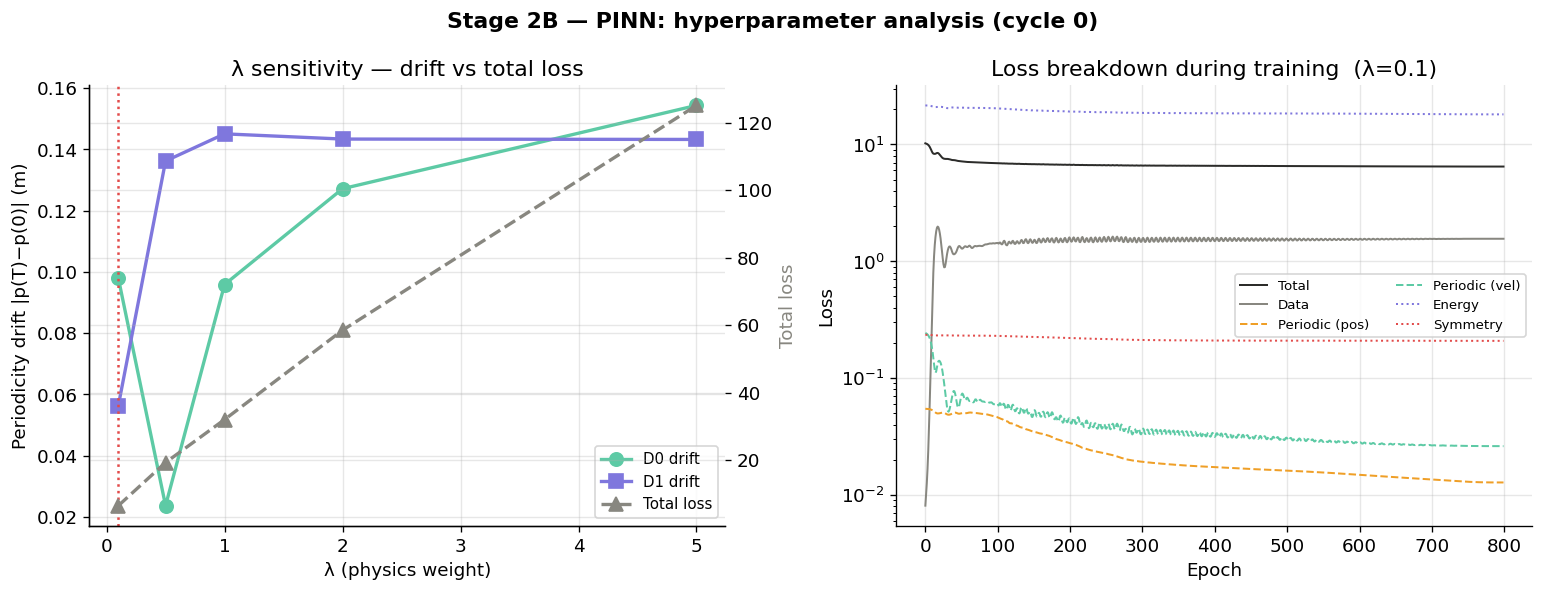

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lams    = list(lam_sweep.keys())
drift0s = [lam_sweep[l]['drift0']      for l in lams]
drift1s = [lam_sweep[l]['drift1']      for l in lams]
losses  = [lam_sweep[l]['log']['total'][-1] for l in lams]

ax2 = axes[0].twinx()
l1, = axes[0].plot(lams, drift0s, 'o-', color=C['dev0'], lw=2, ms=8, label='D0 drift')
l2, = axes[0].plot(lams, drift1s, 's-', color=C['dev1'], lw=2, ms=8, label='D1 drift')
l3, = ax2.plot(lams, losses, '^--', color=C['gray'],  lw=2, ms=8, label='Total loss')
axes[0].axvline(LAM, color=C['naive'], lw=1.5, ls=':', label=f'Selected λ={LAM}')
axes[0].set_xlabel('λ (physics weight)')
axes[0].set_ylabel('Periodicity drift |p(T)−p(0)| (m)')
ax2.set_ylabel('Total loss', color=C['gray'])
axes[0].set_title('λ sensitivity — drift vs total loss')
axes[0].legend(handles=[l1, l2, l3], fontsize=9)

log_sel = lam_sweep[LAM]['log']
style = [
    ('total',      '#2C2C2A', '-',  'Total'),
    ('data',       C['gray'],  '-',  'Data'),
    ('periodic_p', C['pinn'], '--', 'Periodic (pos)'),
    ('periodic_v', C['dev0'], '--', 'Periodic (vel)'),
    ('energy',     C['dev1'], ':',  'Energy'),
    ('symmetry',   C['naive'], ':',  'Symmetry'),
]
for key, col, ls, lbl in style:
    axes[1].plot(log_sel[key], lw=1.2, color=col, ls=ls, label=lbl)
axes[1].set_yscale('log')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title(f'Loss breakdown during training  (λ={LAM})')
axes[1].legend(fontsize=8, ncol=2)

plt.suptitle('Stage 2B — PINN: hyperparameter analysis (cycle 0)', fontweight='bold')
plt.tight_layout()
plt.show()

### 2B.4 — Full Run: All Cycles, Both Devices

In [17]:
print(f'Training PINN on {n_cycles} paired cycles  '
      f'(λ={LAM}, λ_sym=0.5, epochs=2000)\n')
pinn_cycs0, pinn_cycs1 = [], []

for k in range(n_cycles):
    p0c, p1c, log = train_pinn_pair(
        naive_cycs0[k], naive_cycs1[k], A0, A1,
        lam=LAM, lam_sym=0.5, epochs=2000, lr=3e-4)

    pinn_cycs0.append({'p': p0c, 'log': log,
                       't': naive_cycs0[k]['t'],
                       's': naive_cycs0[k]['s'],
                       'e': naive_cycs0[k]['e']})
    pinn_cycs1.append({'p': p1c, 'log': log,
                       't': naive_cycs1[k]['t'],
                       's': naive_cycs1[k]['s'],
                       'e': naive_cycs1[k]['e']})

    d0 = np.linalg.norm(p0c[-1] - p0c[0])
    d1 = np.linalg.norm(p1c[-1] - p1c[0])
    # Print progress every 5 cycles to keep output manageable
    if k % 5 == 0 or k == n_cycles - 1:
        print(f'  Cycle {k:3d}/{n_cycles-1}  '
              f'D0: {naive_drift0[k]:.3f}->{d0:.3f} m  '
              f'D1: {naive_drift1[k]:.3f}->{d1:.3f} m')

pinn_drift0 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn_cycs0]
pinn_drift1 = [np.linalg.norm(c['p'][-1]-c['p'][0]) for c in pinn_cycs1]
red0 = 100*(1 - np.mean(pinn_drift0)/np.mean(naive_drift0))
red1 = 100*(1 - np.mean(pinn_drift1)/np.mean(naive_drift1))

print(f'\nDrift reduction:')
print(f'  Device 0: {np.mean(naive_drift0):.4f} m  ->  '
      f'{np.mean(pinn_drift0):.4f} m  ({red0:.1f}%)')
print(f'  Device 1: {np.mean(naive_drift1):.4f} m  ->  '
      f'{np.mean(pinn_drift1):.4f} m  ({red1:.1f}%)')

Training PINN on 39 paired cycles  (λ=0.1, λ_sym=0.5, epochs=2000)

  Cycle   0/38  D0: 0.134->0.014 m  D1: 0.191->0.012 m
  Cycle   5/38  D0: 0.320->0.041 m  D1: 0.112->0.032 m
  Cycle  10/38  D0: 0.249->0.123 m  D1: 0.152->0.013 m
  Cycle  15/38  D0: 0.088->0.052 m  D1: 0.102->0.072 m
  Cycle  20/38  D0: 0.120->0.105 m  D1: 0.249->0.015 m
  Cycle  25/38  D0: 0.186->0.008 m  D1: 0.108->0.105 m
  Cycle  30/38  D0: 0.139->0.017 m  D1: 0.203->0.047 m
  Cycle  35/38  D0: 0.292->0.091 m  D1: 0.259->0.201 m
  Cycle  38/38  D0: 0.083->0.028 m  D1: 0.125->0.006 m

Drift reduction:
  Device 0: 0.1666 m  ->  0.0584 m  (64.9%)
  Device 1: 0.1585 m  ->  0.0515 m  (67.5%)


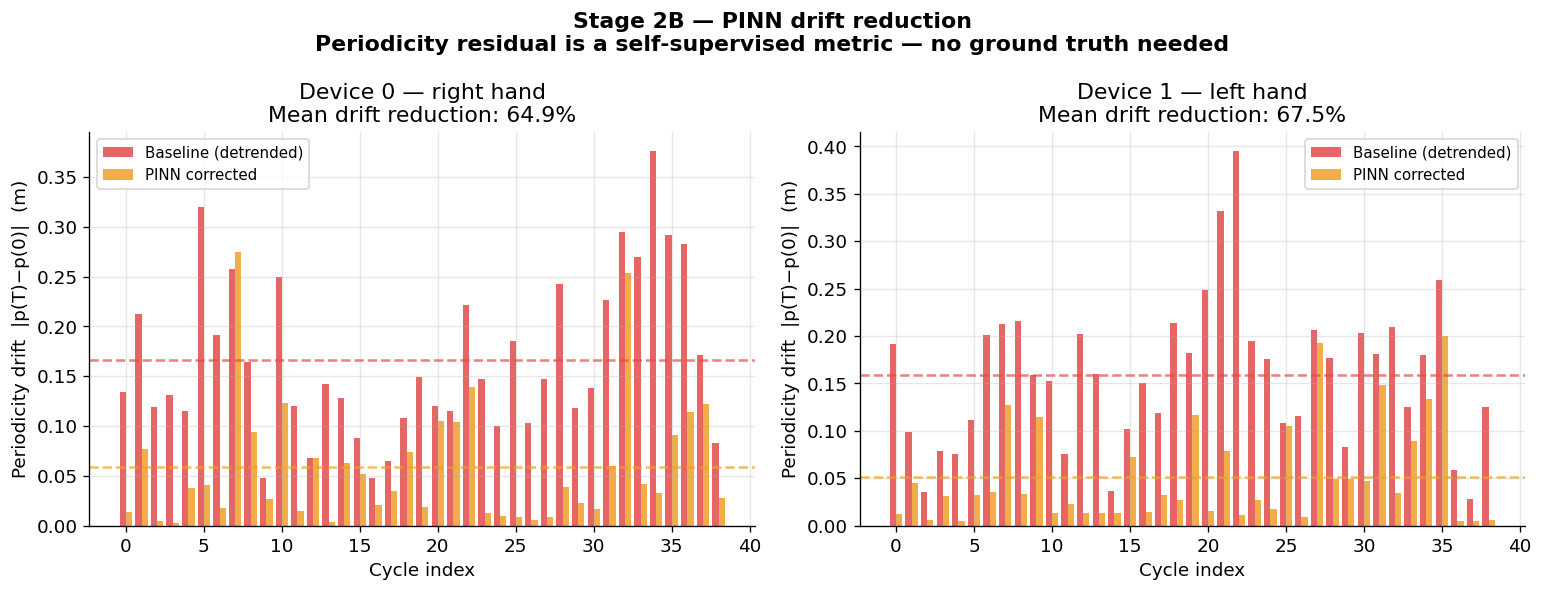

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
x = np.arange(n_cycles)

for ax, nd, pd_, label, red in [
    (axes[0], naive_drift0, pinn_drift0, 'Device 0 — right hand', red0),
    (axes[1], naive_drift1, pinn_drift1, 'Device 1 — left hand',  red1),
]:
    ax.bar(x-0.2, nd,  0.4, color=C['naive'], alpha=0.85, label='Baseline (detrended)')
    ax.bar(x+0.2, pd_, 0.4, color=C['pinn'],  alpha=0.85, label='PINN corrected')
    ax.axhline(np.mean(nd),  color=C['naive'], lw=1.5, ls='--', alpha=0.7)
    ax.axhline(np.mean(pd_), color=C['pinn'],  lw=1.5, ls='--', alpha=0.7)
    ax.set_xlabel('Cycle index')
    ax.set_ylabel('Periodicity drift  |p(T)−p(0)|  (m)')
    ax.set_title(f'{label}\nMean drift reduction: {red:.1f}%')
    ax.legend(fontsize=9)

plt.suptitle('Stage 2B — PINN drift reduction\n'
             'Periodicity residual is a self-supervised metric — no ground truth needed',
             fontweight='bold')
plt.tight_layout()
plt.show()

### 2B.5 — Reconstructed Rope Flow: Both Hands as Rope Extremes

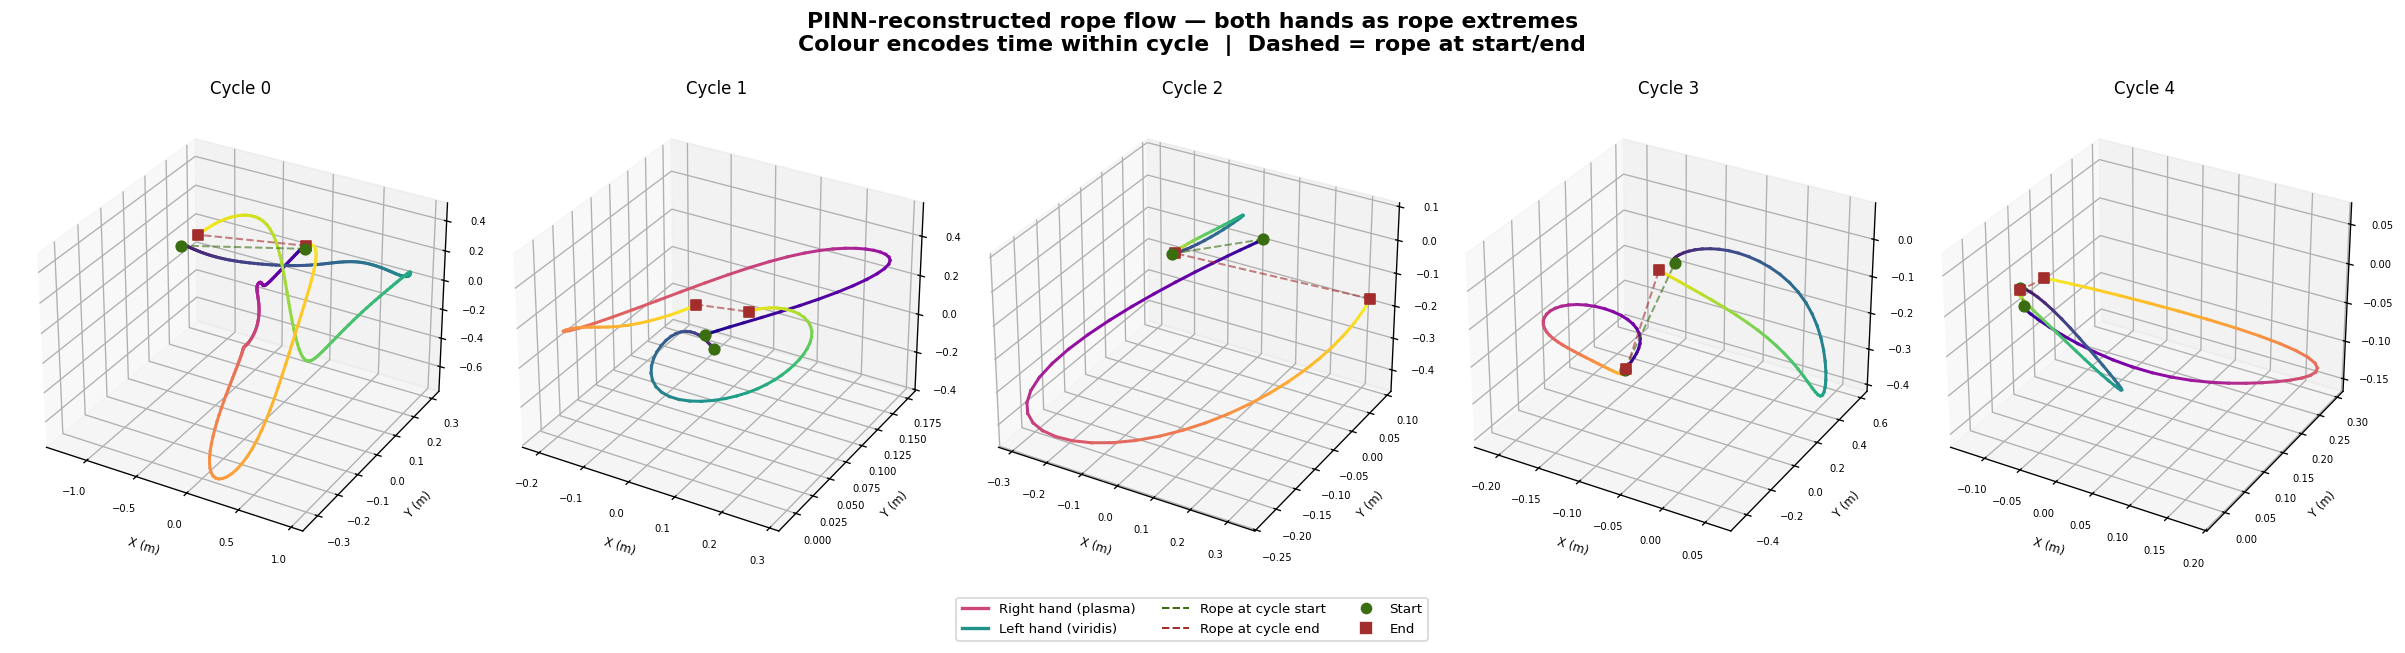

In [19]:
n_show = min(n_cycles, 5)
fig    = plt.figure(figsize=(4*n_show, 5))

for col in range(n_show):
    p0     = pinn_cycs0[col]['p']
    p1     = pinn_cycs1[col]['p']
    n      = min(len(p0), len(p1))
    p0, p1 = p0[:n], p1[:n]
    t_norm = np.linspace(0, 1, n)

    ax = fig.add_subplot(1, n_show, col+1, projection='3d')
    for i in range(n-1):
        ax.plot(p0[i:i+2,0], p0[i:i+2,1], p0[i:i+2,2],
                color=plt.cm.plasma(t_norm[i]),  lw=1.8)
        ax.plot(p1[i:i+2,0], p1[i:i+2,1], p1[i:i+2,2],
                color=plt.cm.viridis(t_norm[i]), lw=1.8)
    ax.scatter(*p0[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p0[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.scatter(*p1[0],  color='#3B6D11', s=40, marker='o', zorder=5)
    ax.scatter(*p1[-1], color='#A32D2D', s=40, marker='s', zorder=5)
    ax.plot([p0[0,0],p1[0,0]], [p0[0,1],p1[0,1]], [p0[0,2],p1[0,2]],
            color='#3B6D11', lw=1.2, ls='--', alpha=0.6)
    ax.plot([p0[-1,0],p1[-1,0]], [p0[-1,1],p1[-1,1]], [p0[-1,2],p1[-1,2]],
            color='#A32D2D', lw=1.2, ls='--', alpha=0.6)
    ax.set_title(f'Cycle {col}', fontsize=10)
    ax.set_xlabel('X (m)', fontsize=7)
    ax.set_ylabel('Y (m)', fontsize=7)
    ax.set_zlabel('Z (m)', fontsize=7)
    ax.tick_params(labelsize=6)

fig.legend(handles=[
    Line2D([0],[0], color=plt.cm.plasma(0.5),  lw=2, label='Right hand (plasma)'),
    Line2D([0],[0], color=plt.cm.viridis(0.5), lw=2, label='Left hand (viridis)'),
    Line2D([0],[0], color='#3B6D11', lw=1.2, ls='--', label='Rope at cycle start'),
    Line2D([0],[0], color='#A32D2D', lw=1.2, ls='--', label='Rope at cycle end'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='#3B6D11', ms=8, label='Start'),
    Line2D([0],[0], marker='s', color='w', markerfacecolor='#A32D2D', ms=8, label='End'),
], loc='lower center', ncol=3, fontsize=8, bbox_to_anchor=(0.5, -0.08))

plt.suptitle('PINN-reconstructed rope flow — both hands as rope extremes\n'
             'Colour encodes time within cycle  |  Dashed = rope at start/end',
             fontweight='bold')
plt.tight_layout()
plt.show()

---
## Stage 2C — DMD + PCA: Feature Extraction for Classification

**Goal**: Compress each paired cycle into a compact feature vector for Stage 3 classification.

**DMD** — linear spectral decomposition of the combined rope state $[\mathbf{p}_0, \mathbf{p}_1, \mathbf{a}_0, \boldsymbol{\omega}_0, \mathbf{a}_1, \boldsymbol{\omega}_1] \in \mathbb{R}^{18}$. Extracts dominant oscillation frequencies and spatial modes from both hands simultaneously.

**PCA** — optimal linear dimensionality reduction. Preferred over an autoencoder here because with ~50 cycles an autoencoder would be severely data-starved. PCA is the exact solution to linear compression, requires no training, and produces interpretable modes.

### 2C.1 — Dynamic Mode Decomposition

In [20]:
def compute_dmd(X, dt, var_threshold=0.99):
    """
    Exact DMD with automatic rank selection.
    Rank r is chosen as the minimum number of SVD modes that
    explain var_threshold of the total variance in X.
    """
    X1, X2   = X[:, :-1], X[:, 1:]
    U, S, Vh = svd(X1, full_matrices=False)
    r        = int(np.searchsorted(np.cumsum(S**2)/np.sum(S**2),
                                   var_threshold)) + 1
    U_r, S_r, Vh_r = U[:,:r], S[:r], Vh[:r,:]
    A_tilde  = U_r.T @ X2 @ Vh_r.T @ np.diag(1.0/S_r)
    lam_d, W = np.linalg.eig(A_tilde)
    Phi      = X2 @ Vh_r.T @ np.diag(1.0/S_r) @ W
    lam_c    = np.log(lam_d + 1e-12) / dt
    b        = np.linalg.lstsq(Phi, X[:,0], rcond=None)[0]
    return lam_c, Phi, np.abs(lam_c.imag)/(2*np.pi), lam_c.real, b, r, S


dmd_results = []
for k in range(n_cycles):
    c0, c1 = pinn_cycs0[k], pinn_cycs1[k]
    n      = min(c0['e']-c0['s'], c1['e']-c1['s'])
    state  = np.hstack([
        c0['p'][:n], c1['p'][:n],
        A0[c0['s']:c0['s']+n], om0[c0['s']:c0['s']+n],
        A1[c1['s']:c1['s']+n], om1[c1['s']:c1['s']+n],
    ]).T   # (18, n)
    tc     = c0['t'][:n]
    dt_    = float(np.median(np.diff(tc)))
    lam_c, Phi, freqs, growth, b, r, S = compute_dmd(state, dt_)
    T      = tc - tc[0]
    X_rec  = (Phi @ np.array([b[j]*np.exp(lam_c[j]*T) for j in range(r)])).real
    dmd_results.append({
        'lam_c': lam_c, 'freqs': freqs, 'growth': growth,
        'b': b, 'r': r, 'S': S,
        'state': state, 'X_rec': X_rec, 't': tc,
        'rec_mse': float(np.mean((state - X_rec)**2))
    })

ranks  = [r['r']       for r in dmd_results]
mses   = [r['rec_mse'] for r in dmd_results]
print(f'DMD complete: {n_cycles} cycles')
print(f'  Rank:    mean={np.mean(ranks):.1f}  range=[{min(ranks)}, {max(ranks)}]')
print(f'  Rec MSE: mean={np.mean(mses):.6f}  std={np.std(mses):.6f}')

DMD complete: 39 cycles
  Rank:    mean=5.4  range=[4, 7]
  Rec MSE: mean=29949.031604  std=184151.502700


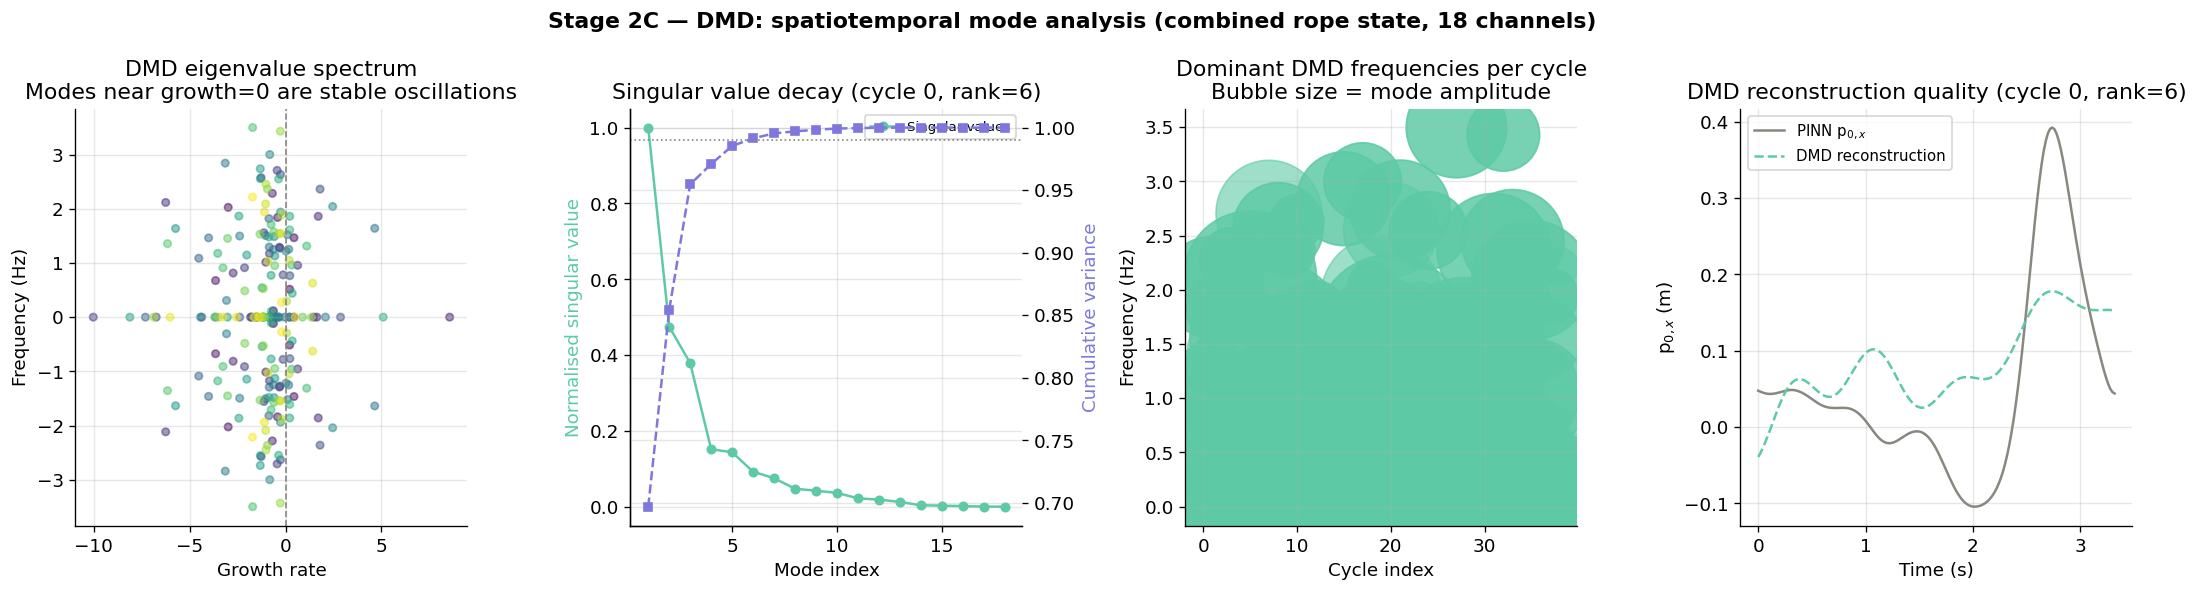

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

# Eigenvalue spectrum: modes near the imaginary axis (growth ~ 0) are stable
# oscillatory modes — exactly what we expect for periodic rope flow
for k, res in enumerate(dmd_results):
    axes[0].scatter(res['lam_c'].real, res['lam_c'].imag/(2*np.pi),
                    s=20, alpha=0.5, c=[k]*len(res['lam_c']),
                    cmap='viridis', vmin=0, vmax=n_cycles-1)
axes[0].axvline(0, color=C['gray'], lw=1.0, ls='--')
axes[0].set_xlabel('Growth rate')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_title('DMD eigenvalue spectrum\nModes near growth=0 are stable oscillations')

# Singular value decay: justifies the rank truncation at 99% variance
S_ref  = dmd_results[0]['S']
cumv   = np.cumsum(S_ref**2) / np.sum(S_ref**2)
axes[1].plot(range(1, len(S_ref)+1), S_ref/S_ref[0],
             'o-', color=C['dev0'], ms=5, lw=1.5, label='Singular values')
ax1b = axes[1].twinx()
ax1b.plot(range(1, len(cumv)+1), cumv,
          's--', color=C['dev1'], ms=5, lw=1.5, label='Cumulative variance')
ax1b.axhline(0.99, color=C['gray'], lw=1, ls=':', label='99% threshold')
ax1b.set_ylabel('Cumulative variance', color=C['dev1'])
axes[1].set_xlabel('Mode index')
axes[1].set_ylabel('Normalised singular value', color=C['dev0'])
axes[1].set_title(f'Singular value decay (cycle 0, rank={dmd_results[0]["r"]})')
axes[1].legend(fontsize=8, loc='upper right')

# Dominant frequencies: bubble size = mode amplitude
# Consistent frequency across cycles = stable rope flow signature
for k, res in enumerate(dmd_results):
    top = np.argsort(np.abs(res['b']))[::-1][:5]
    axes[2].scatter([k]*len(top), res['freqs'][top],
                    s=np.abs(res['b'][top])*200+10, color=C['dev0'], alpha=0.6)
axes[2].set_xlabel('Cycle index')
axes[2].set_ylabel('Frequency (Hz)')
axes[2].set_title('Dominant DMD frequencies per cycle\nBubble size = mode amplitude')

# Reconstruction quality on one cycle
res0 = dmd_results[0]
axes[3].plot(res0['t'], res0['state'][0],
             color=C['gray'], lw=1.5, label='PINN p$_{0,x}$')
axes[3].plot(res0['t'], res0['X_rec'][0],
             color=C['dev0'], lw=1.5, ls='--', label='DMD reconstruction')
axes[3].set_xlabel('Time (s)')
axes[3].set_ylabel('p$_{0,x}$ (m)')
axes[3].set_title(f'DMD reconstruction quality (cycle 0, rank={res0["r"]})')
axes[3].legend(fontsize=9)

plt.suptitle('Stage 2C — DMD: spatiotemporal mode analysis (combined rope state, 18 channels)',
             fontweight='bold')
plt.tight_layout()
plt.show()

### 2C.2 — PCA: Latent Representation with Dimension Sweep

In [22]:
TARGET_LEN = 64

def build_cycle_matrix(pinn_cycs0, pinn_cycs1, A0_f, om0_f, A1_f, om1_f, tlen=64):
    """
    Build (n_cycles, 18*tlen) feature matrix.
    Each cycle is resampled to tlen timesteps and normalised per channel
    (zero mean, unit std) so channels with larger physical magnitudes
    do not dominate the PCA.
    Channels: [p0_xyz, p1_xyz, a0_xyz, om0_xyz, a1_xyz, om1_xyz]
    """
    rows = []
    for c0, c1 in zip(pinn_cycs0, pinn_cycs1):
        s0, e0, s1, e1 = c0['s'], c0['e'], c1['s'], c1['e']
        n     = min(e0-s0, e1-s1)
        state = np.hstack([
            c0['p'][:n], c1['p'][:n],
            A0_f[s0:s0+n], om0_f[s0:s0+n],
            A1_f[s1:s1+n], om1_f[s1:s1+n],
        ]).T
        t_old = np.linspace(0, 1, n)
        t_new = np.linspace(0, 1, tlen)
        res   = np.array([interp1d(t_old, state[c])(t_new) for c in range(18)])
        mn    = res.mean(axis=1, keepdims=True)
        sd    = res.std(axis=1,  keepdims=True) + 1e-8
        rows.append(((res - mn) / sd).ravel())
    return np.array(rows)


X_cycles = build_cycle_matrix(
    pinn_cycs0, pinn_cycs1, A0, om0, A1, om1, TARGET_LEN)
print(f'Cycle matrix: {X_cycles.shape}  '
      f'({n_cycles} cycles × {18*TARGET_LEN} features)')

latent_dims = [2, 4, 8, 16, 32]
pca_results = {}
print(f'\nPCA latent dimension sweep:')
for d in latent_dims:
    pca = PCA(n_components=d)
    Z   = pca.fit_transform(X_cycles)
    mse = float(np.mean((X_cycles - pca.inverse_transform(Z))**2))
    var = float(pca.explained_variance_ratio_.sum())
    pca_results[d] = {'pca': pca, 'Z': Z, 'mse': mse, 'var': var}
    print(f'  dim={d:2d}  explained var={var:.3f}  rec MSE={mse:.6f}')

# Select the smallest dimension that explains at least 70% of variance
LATENT_DIM = min((d for d in latent_dims if pca_results[d]['var'] >= 0.70),
                 default=latent_dims[-1])
pca_best  = pca_results[LATENT_DIM]['pca']
latent_np = pca_results[LATENT_DIM]['Z']
print(f'\nSelected latent dim: {LATENT_DIM}  '
      f'(first dim with explained var >= 70%)')

Cycle matrix: (39, 1152)  (39 cycles × 1152 features)

PCA latent dimension sweep:
  dim= 2  explained var=0.182  rec MSE=0.791643
  dim= 4  explained var=0.331  rec MSE=0.647931
  dim= 8  explained var=0.542  rec MSE=0.443779
  dim=16  explained var=0.790  rec MSE=0.203029
  dim=32  explained var=0.980  rec MSE=0.019618

Selected latent dim: 16  (first dim with explained var >= 70%)


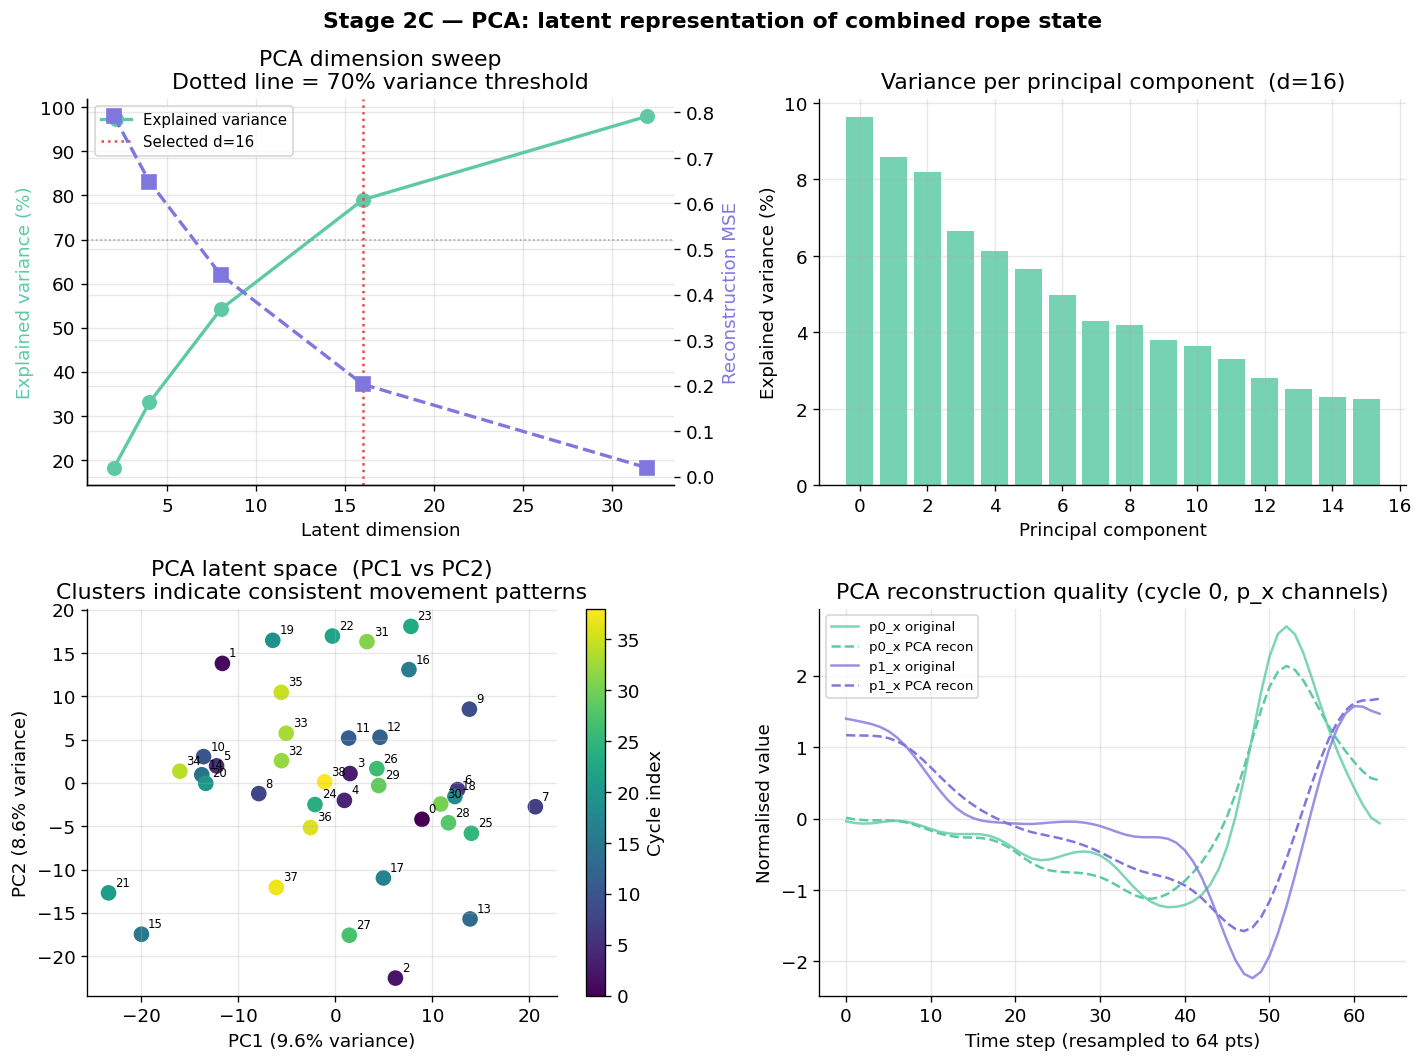

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# Latent dim sweep: variance vs reconstruction tradeoff
dims  = list(pca_results.keys())
vars_ = [pca_results[d]['var'] for d in dims]
mses  = [pca_results[d]['mse'] for d in dims]

axes[0,0].plot(dims, [v*100 for v in vars_], 'o-', color=C['dev0'], ms=8, lw=2,
               label='Explained variance')
ax_r = axes[0,0].twinx()
ax_r.plot(dims, mses, 's--', color=C['dev1'], ms=8, lw=2, label='Rec MSE')
axes[0,0].axvline(LATENT_DIM, color=C['naive'], lw=1.5, ls=':', label=f'Selected d={LATENT_DIM}')
axes[0,0].axhline(70, color=C['gray'], lw=1, ls=':', alpha=0.7)
axes[0,0].set_xlabel('Latent dimension')
axes[0,0].set_ylabel('Explained variance (%)', color=C['dev0'])
ax_r.set_ylabel('Reconstruction MSE', color=C['dev1'])
axes[0,0].set_title('PCA dimension sweep\nDotted line = 70% variance threshold')
axes[0,0].legend(fontsize=9)

# Variance per component: shows how many PCs carry meaningful variance
evr = pca_best.explained_variance_ratio_
axes[0,1].bar(range(LATENT_DIM), evr*100, color=C['dev0'], alpha=0.85)
axes[0,1].set_xlabel('Principal component')
axes[0,1].set_ylabel('Explained variance (%)')
axes[0,1].set_title(f'Variance per principal component  (d={LATENT_DIM})')

# Latent space scatter: each point is one cycle.
# Clusters = similar movement patterns — key for Stage 3 classifier.
sc = axes[1,0].scatter(latent_np[:,0], latent_np[:,1],
                        c=range(n_cycles), cmap='viridis', s=70)
for k in range(n_cycles):
    axes[1,0].annotate(str(k), (latent_np[k,0], latent_np[k,1]),
                       textcoords='offset points', xytext=(4,4), fontsize=7)
plt.colorbar(sc, ax=axes[1,0], label='Cycle index')
axes[1,0].set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
axes[1,0].set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
axes[1,0].set_title('PCA latent space  (PC1 vs PC2)\n'
                    'Clusters indicate consistent movement patterns')

# Reconstruction quality: original vs PCA reconstruction for cycle 0
orig = X_cycles[0].reshape(18, TARGET_LEN)
rec  = pca_best.inverse_transform(latent_np[0].reshape(1, -1)).reshape(18, TARGET_LEN)
for i, (lbl, col) in enumerate([('p0_x', C['dev0']), ('p1_x', C['dev1'])]):
    axes[1,1].plot(orig[i], color=col, lw=1.5, alpha=0.8, label=f'{lbl} original')
    axes[1,1].plot(rec[i],  color=col, lw=1.5, ls='--',   label=f'{lbl} PCA recon')
axes[1,1].set_xlabel('Time step (resampled to 64 pts)')
axes[1,1].set_ylabel('Normalised value')
axes[1,1].set_title('PCA reconstruction quality (cycle 0, p_x channels)')
axes[1,1].legend(fontsize=8)

plt.suptitle('Stage 2C — PCA: latent representation of combined rope state',
             fontweight='bold')
plt.tight_layout()
plt.show()

### 2C.3 — Combined Feature Matrix

The final feature vector per cycle concatenates:
- **DMD features**: top-3 dominant frequencies and their growth rates (6 values) — physics-motivated spectral signature
- **PCA features**: first 4 principal component scores (4 values) — data-driven shape representation

This 10-dimensional vector is the input to the Stage 3 classifier.

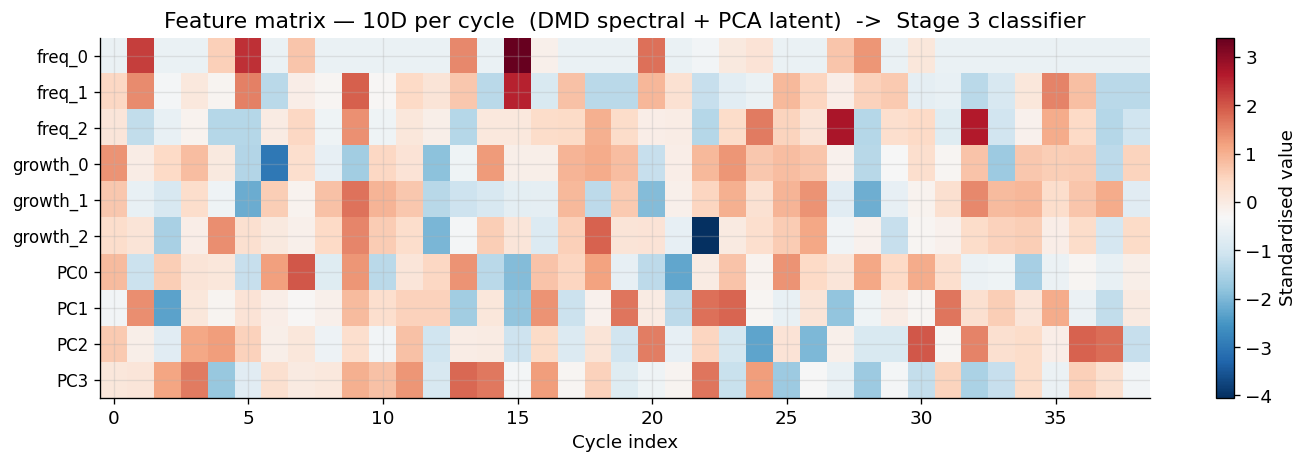

Feature matrix shape: (39, 10)  (39 cycles × 10 features)


In [25]:
def extract_features(dmd_res, lat_vec, n_dmd=3):
    """Concatenate top-n DMD spectral features with PCA latent codes."""
    top = np.argsort(np.abs(dmd_res['b']))[::-1][:n_dmd]
    return np.concatenate([dmd_res['freqs'][top], dmd_res['growth'][top], lat_vec[:4]])

all_features = np.array([
    extract_features(dmd_results[k], latent_np[k]) for k in range(n_cycles)
])
feat_labels = ([f'freq_{i}'   for i in range(3)] +
               [f'growth_{i}' for i in range(3)] +
               [f'PC{i}'      for i in range(4)])

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(StandardScaler().fit_transform(all_features).T,
               aspect='auto', cmap='RdBu_r', interpolation='nearest')
ax.set_yticks(range(len(feat_labels)))
ax.set_yticklabels(feat_labels, fontsize=10)
ax.set_xlabel('Cycle index')
ax.set_title(f'Feature matrix — {all_features.shape[1]}D per cycle  '
             f'(DMD spectral + PCA latent)  ->  Stage 3 classifier')
plt.colorbar(im, ax=ax, label='Standardised value')
plt.tight_layout()
plt.show()

print(f'Feature matrix shape: {all_features.shape}  '
      f'({n_cycles} cycles × {all_features.shape[1]} features)')

---
## Pipeline Summary

In [26]:
print('=' * 60)
print('STAGE 2 — PIPELINE SUMMARY')
print('=' * 60)

print('\nStage 2A — SINDy  (orientation state, joint fit)')
print(f'  State:           [sin_r, cos_r, pitch, sin_y, cos_y, wx, wy, wz]')
print(f'  Selected thresh: {BEST_TH}')
print(f'  R² Device 0:     {best_model.score(O0, t=t0):.4f}  (train)')
print(f'  R² Device 1:     {best_model.score(O1, t=t1):.4f}  (cross-device)')
print(f'  Active terms:    {sindy_sweep[BEST_TH]["n_active"]}  '
      f'({sindy_sweep[BEST_TH]["sparsity"]:.1%} sparse)')

print('\nStage 2B — PINN  (joint training, rich physics)')
print(f'  Architecture:    MLP [8->128x4->3], Tanh, Xavier init')
print(f'  Loss:            5x periodic_p + 2x periodic_v + 1x data')
print(f'                   + λ(boundary+jerk+energy) + λ_sym(symmetry)')
print(f'  Selected λ:      {LAM}')
print(f'  Baseline drift:  D0={np.mean(naive_drift0):.4f} m  '
      f'D1={np.mean(naive_drift1):.4f} m')
print(f'  PINN drift:      D0={np.mean(pinn_drift0):.4f} m ({red0:.1f}% reduction)  '
      f'D1={np.mean(pinn_drift1):.4f} m ({red1:.1f}% reduction)')

print('\nStage 2C — DMD + PCA  (combined rope state, 18 channels)')
print(f'  DMD mean rank:   {np.mean([r["r"] for r in dmd_results]):.1f}')
print(f'  PCA latent dim:  {LATENT_DIM}')
print(f'  PCA expl. var:   {pca_results[LATENT_DIM]["var"]:.3f}')
print(f'  Feature matrix:  {all_features.shape}  -> Stage 3 classifier')
print('=' * 60)

STAGE 2 — PIPELINE SUMMARY

Stage 2A — SINDy  (orientation state, joint fit)
  State:           [sin_r, cos_r, pitch, sin_y, cos_y, wx, wy, wz]
  Selected thresh: 0.4
  R² Device 0:     0.3196  (train)
  R² Device 1:     0.3653  (cross-device)
  Active terms:    197  (59.6% sparse)

Stage 2B — PINN  (joint training, rich physics)
  Architecture:    MLP [8->128x4->3], Tanh, Xavier init
  Loss:            5x periodic_p + 2x periodic_v + 1x data
                   + λ(boundary+jerk+energy) + λ_sym(symmetry)
  Selected λ:      0.1
  Baseline drift:  D0=0.1666 m  D1=0.1585 m
  PINN drift:      D0=0.0584 m (64.9% reduction)  D1=0.0515 m (67.5% reduction)

Stage 2C — DMD + PCA  (combined rope state, 18 channels)
  DMD mean rank:   5.4
  PCA latent dim:  16
  PCA expl. var:   0.790
  Feature matrix:  (39, 10)  -> Stage 3 classifier
